# Pothole Detection v3 — Prophet on Z-Axis Acceleration

### Approach (Gemini-suggested unsupervised method)
1. **Model "normal" road** using FB Prophet on TotalAcceleration Z-axis (~9.81 m/s² on smooth road)
2. **Out-of-bounds detection**: anomaly = actual Z falls outside `[yhat_lower, yhat_upper]`
3. **Speed as extra regressor**: Prophet learns to expect more vibration at higher speeds
4. **Severity score**: how far the reading deviates beyond the bounds
5. **Gyroscope for classification**: Pothole = high gyro rotation (vehicle rocks), Braking = low gyro + high X-accel
6. **DBSCAN clustering** → Leaflet map with color-coded markers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import folium
import warnings, os, gc, logging
from sklearn.cluster import DBSCAN

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
plt.style.use('seaborn-v0_8-darkgrid')
print('Ready.')

Ready.


## 1. Load All Sensor Data

In [2]:
DATA_ROOT = os.path.join('..', '')  # data folders in parent
folders = ['A', 'B', 'C', 'D', 'E', 'F']

def load_route(folder):
    base = os.path.join(DATA_ROOT, folder)
    gyro = pd.read_csv(os.path.join(base, 'Gyroscope.csv'),
                       dtype={'x':'float32','y':'float32','z':'float32','seconds_elapsed':'float32'})
    accel = pd.read_csv(os.path.join(base, 'Accelerometer.csv'),
                        dtype={'x':'float32','y':'float32','z':'float32','seconds_elapsed':'float32'})
    total = pd.read_csv(os.path.join(base, 'TotalAcceleration.csv'),
                        dtype={'x':'float32','y':'float32','z':'float32','seconds_elapsed':'float32'})
    loc = pd.read_csv(os.path.join(base, 'Location.csv'),
                      dtype={'latitude':'float64','longitude':'float64',
                             'altitude':'float32','speed':'float32','seconds_elapsed':'float32'})
    return gyro, accel, total, loc

all_data = {}
for f in folders:
    gyro, accel, total, loc = load_route(f)
    all_data[f] = {'gyro': gyro, 'accel': accel, 'total': total, 'location': loc}
    print(f'Route {f}: gyro={len(gyro):,}  accel={len(accel):,}  total={len(total):,}  loc={len(loc):,}')

print('\nAll data loaded.')

Route A: gyro=13,255  accel=13,249  total=13,246  loc=138
Route B: gyro=31,531  accel=31,524  total=31,532  loc=327
Route C: gyro=12,108  accel=12,108  total=12,111  loc=126
Route D: gyro=34,022  accel=34,020  total=34,020  loc=353
Route E: gyro=38,639  accel=38,632  total=38,631  loc=400
Route F: gyro=19,898  accel=19,897  total=19,899  loc=206

All data loaded.


## 2. Interpolate Speed onto Sensor Timestamps
GPS is ~1 Hz, sensors are ~100 Hz. We interpolate speed so every sensor sample has a speed value.  
Also detect **start/stop phases** to filter false positives from car jerk.

In [3]:
def compute_speed_context(gyro_df, loc_df, lookback_sec=3.0):
    """Interpolate GPS speed onto sensor timestamps + detect start/stop phases."""
    sensor_t = gyro_df['seconds_elapsed'].values.astype('float64')
    gps_t = loc_df['seconds_elapsed'].values.astype('float64')
    gps_speed = loc_df['speed'].values.astype('float64')

    interp_speed = np.interp(sensor_t, gps_t, gps_speed)
    gps_accel = np.gradient(interp_speed, sensor_t)

    # Start phase: speed was < 1 m/s within last lookback_sec
    is_start = np.zeros(len(sensor_t), dtype=bool)
    is_stop  = np.zeros(len(sensor_t), dtype=bool)

    for i in range(len(sensor_t)):
        t_now = sensor_t[i]
        # Look back
        mask_back = (sensor_t >= t_now - lookback_sec) & (sensor_t <= t_now)
        if interp_speed[mask_back].min() < 1.0:
            is_start[i] = True
        # Look forward
        mask_fwd = (sensor_t >= t_now) & (sensor_t <= t_now + lookback_sec)
        if interp_speed[mask_fwd].min() < 1.0:
            is_stop[i] = True

    ctx = pd.DataFrame({
        'seconds_elapsed': sensor_t,
        'speed': interp_speed,
        'gps_accel': gps_accel,
        'is_start_phase': is_start,
        'is_stop_phase': is_stop
    })
    return ctx

for f in folders:
    d = all_data[f]
    ctx = compute_speed_context(d['gyro'], d['location'])
    d['speed_ctx'] = ctx
    n_start = ctx['is_start_phase'].sum()
    n_stop = ctx['is_stop_phase'].sum()
    print(f'Route {f}: speed range {ctx["speed"].min()*3.6:.1f}-{ctx["speed"].max()*3.6:.1f} km/h, '
          f'start_phase={n_start}, stop_phase={n_stop}')

print('\nSpeed context computed for all routes.')

Route A: speed range 0.0-40.6 km/h, start_phase=754, stop_phase=465
Route B: speed range 0.0-28.0 km/h, start_phase=20711, stop_phase=20996
Route C: speed range 5.2-64.4 km/h, start_phase=0, stop_phase=0
Route D: speed range 0.0-44.2 km/h, start_phase=23057, stop_phase=23056
Route E: speed range 0.0-45.1 km/h, start_phase=6252, stop_phase=5963
Route F: speed range 0.0-46.0 km/h, start_phase=3721, stop_phase=3719

Speed context computed for all routes.


## 3. Prophet Anomaly Detection on Z-Axis Acceleration

**Key change from v2:** Instead of Prophet on gyroscope, we use it on **TotalAcceleration Z**.

- On smooth road: Z ≈ 9.81 m/s² (gravity)
- Pothole: Z drops sharply (freefall) then spikes (bounce)
- Speed breaker: Z oscillates up/down
- Prophet learns the "normal" baseline with `interval_width` confidence bounds
- **Anomaly = actual Z outside `[yhat_lower, yhat_upper]`**
- Speed added as **extra regressor** so Prophet expects more vibration at higher speeds

In [4]:
def prophet_z_accel(seconds_elapsed, z_values, speed_values,
                    interval_width=0.99, cp_scale=0.15):
    """
    Prophet on Z-axis TotalAcceleration with speed as extra regressor.
    Returns:
      - anomaly_mask: bool array (True = outside bounds)
      - deviation: how far outside the bounds (signed: negative=dip, positive=bump)
      - forecast_df: full Prophet forecast for plotting
    """
    # Prophet needs 'ds' as datetime and 'y' as the target
    ds = pd.to_datetime(seconds_elapsed, unit='s')
    df = pd.DataFrame({
        'ds': ds,
        'y': z_values.astype('float64'),
        'speed': speed_values.astype('float64')
    })

    m = Prophet(
        daily_seasonality=False,
        yearly_seasonality=False,
        weekly_seasonality=False,
        changepoint_prior_scale=cp_scale,
        interval_width=interval_width,  # KEY: confidence bounds
    )
    m.add_regressor('speed')  # speed as extra regressor
    m.fit(df)

    forecast = m.predict(df)

    y = df['y'].values
    yhat = forecast['yhat'].values
    yhat_lower = forecast['yhat_lower'].values
    yhat_upper = forecast['yhat_upper'].values

    # Anomaly: outside the bounds
    anomaly = (y < yhat_lower) | (y > yhat_upper)

    # Deviation: how far outside (positive = above upper, negative = below lower)
    deviation = np.zeros_like(y)
    above = y > yhat_upper
    below = y < yhat_lower
    deviation[above] = y[above] - yhat_upper[above]  # bump magnitude
    deviation[below] = y[below] - yhat_lower[below]  # dip magnitude (negative)

    del m; gc.collect()
    return anomaly, deviation, forecast

print('Prophet Z-accel function ready.')

Prophet Z-accel function ready.


In [5]:
# Run Prophet on Z-axis TotalAcceleration for all routes
results = {}
for folder in folders:
    print(f'\n{"="*50}  Route {folder}  {"="*50}')
    d = all_data[folder]
    total = d['total']
    ctx = d['speed_ctx']

    # Interpolate speed onto total_accel timestamps
    speed_interp = np.interp(
        total['seconds_elapsed'].values,
        ctx['seconds_elapsed'].values,
        ctx['speed'].values
    )

    anomaly, deviation, forecast = prophet_z_accel(
        total['seconds_elapsed'].values,
        total['z'].values,
        speed_interp,
        interval_width=0.99,
        cp_scale=0.15
    )

    results[folder] = {
        'anomaly': anomaly,
        'deviation': deviation,
        'forecast': forecast,
        'speed_interp': speed_interp
    }

    n_anom = int(anomaly.sum())
    n_dip = int((deviation < 0).sum())
    n_bump = int((deviation > 0).sum())
    print(f'  Anomalies: {n_anom}/{len(total)} ({100*n_anom/len(total):.2f}%)')
    print(f'  Dips (below lower): {n_dip},  Bumps (above upper): {n_bump}')
    print(f'  Max dip deviation: {deviation.min():.2f} m/s²')
    print(f'  Max bump deviation: {deviation.max():.2f} m/s²')
    gc.collect()

print('\nProphet Z-accel detection done for all routes.')


==================================================  Route A  ==================================================


15:43:20 - cmdstanpy - INFO - Chain [1] start processing
15:43:21 - cmdstanpy - INFO - Chain [1] done processing


  Anomalies: 293/13246 (2.21%)
  Dips (below lower): 149,  Bumps (above upper): 144
  Max dip deviation: -8.26 m/s²
  Max bump deviation: 12.26 m/s²

==================================================  Route B  ==================================================


15:43:24 - cmdstanpy - INFO - Chain [1] start processing
15:43:26 - cmdstanpy - INFO - Chain [1] done processing


  Anomalies: 896/31532 (2.84%)
  Dips (below lower): 462,  Bumps (above upper): 434
  Max dip deviation: -7.55 m/s²
  Max bump deviation: 9.24 m/s²

==================================================  Route C  ==================================================


...

  Anomalies: 796/34020 (2.34%)
  Dips (below lower): 409,  Bumps (above upper): 387
  Max dip deviation: -24.01 m/s²
  Max bump deviation: 30.18 m/s²

==================================================  Route E  ==================================================


15:43:38 - cmdstanpy - INFO - Chain [1] start processing
15:43:40 - cmdstanpy - INFO - Chain [1] done processing


  Anomalies: 660/38631 (1.71%)
  Dips (below lower): 357,  Bumps (above upper): 303
  Max dip deviation: -24.79 m/s²
  Max bump deviation: 39.68 m/s²

==================================================  Route F  ==================================================


15:43:44 - cmdstanpy - INFO - Chain [1] start processing
15:43:44 - cmdstanpy - INFO - Chain [1] done processing


  Anomalies: 475/19899 (2.39%)
  Dips (below lower): 240,  Bumps (above upper): 235
  Max dip deviation: -13.94 m/s²
  Max bump deviation: 31.83 m/s²

Prophet Z-accel detection done for all routes.


## 4. Visualize Prophet Bounds (Z-Accel + detected anomalies)
Blue = normal range (yhat_lower to yhat_upper), Red dots = anomalies outside bounds

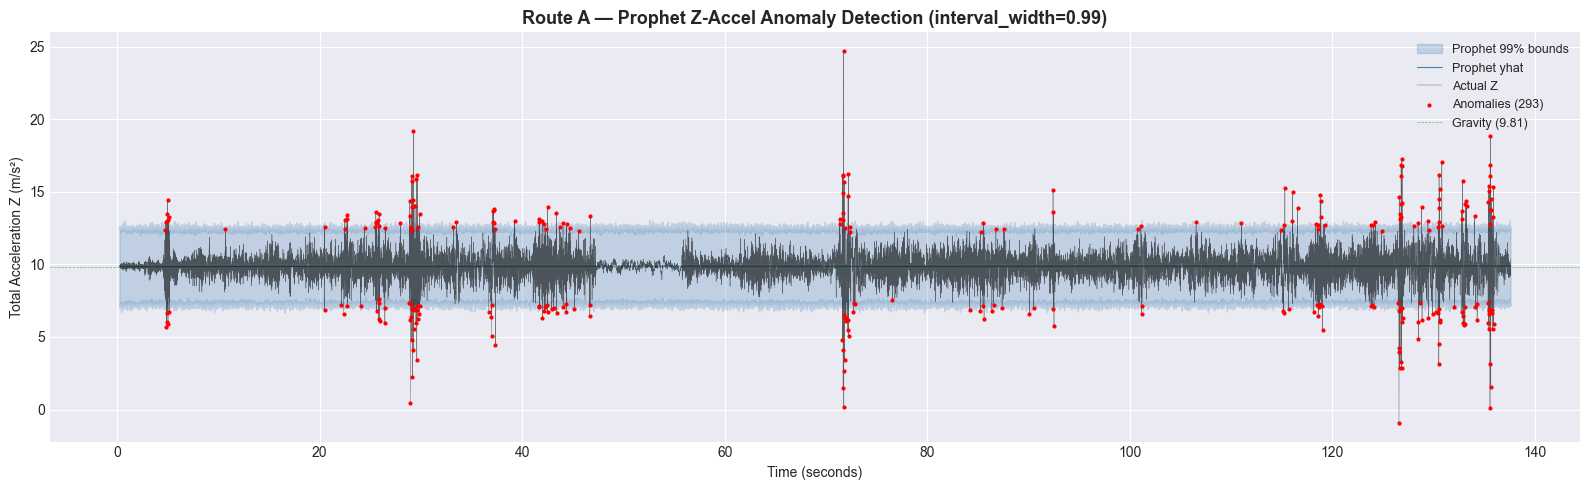

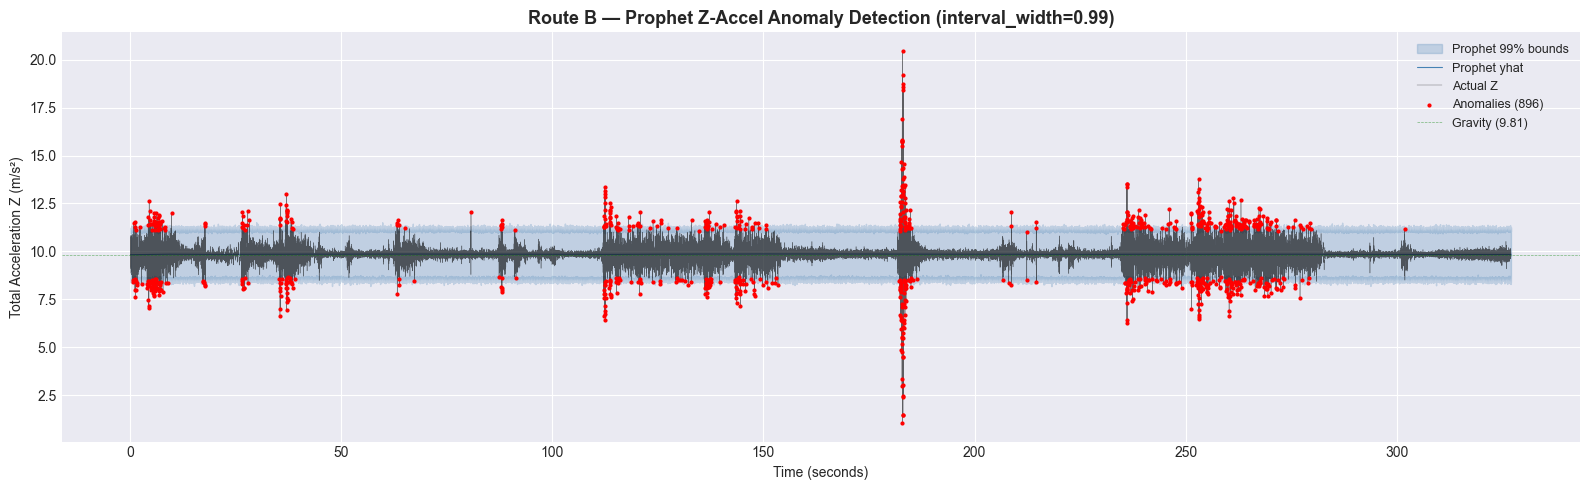

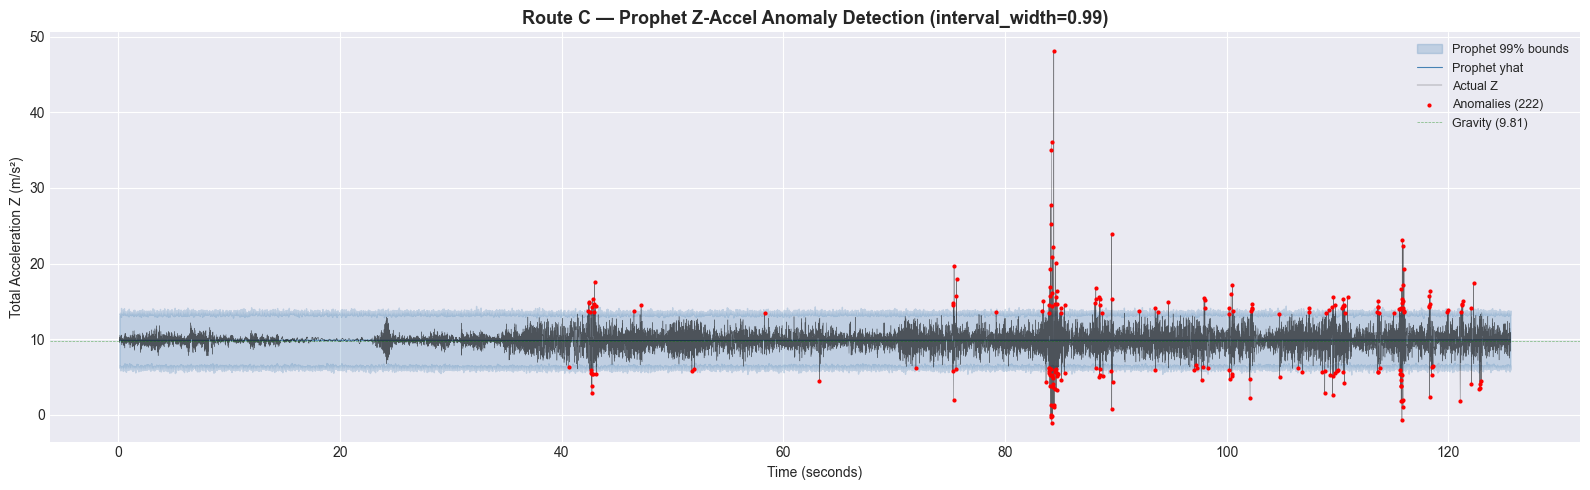

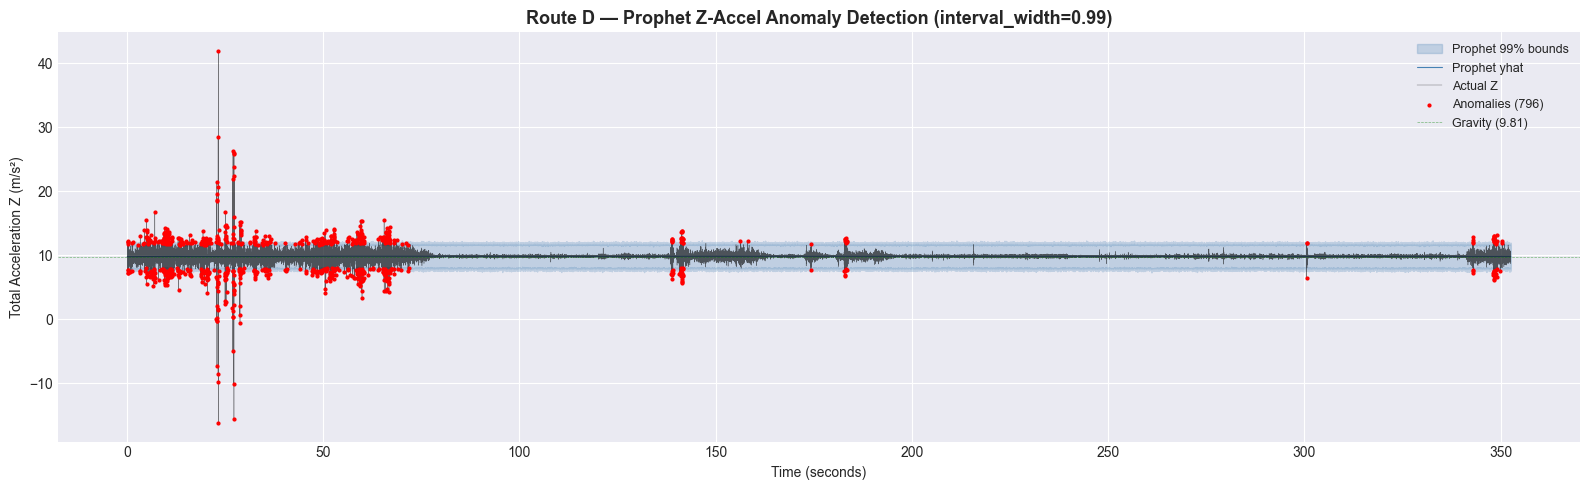

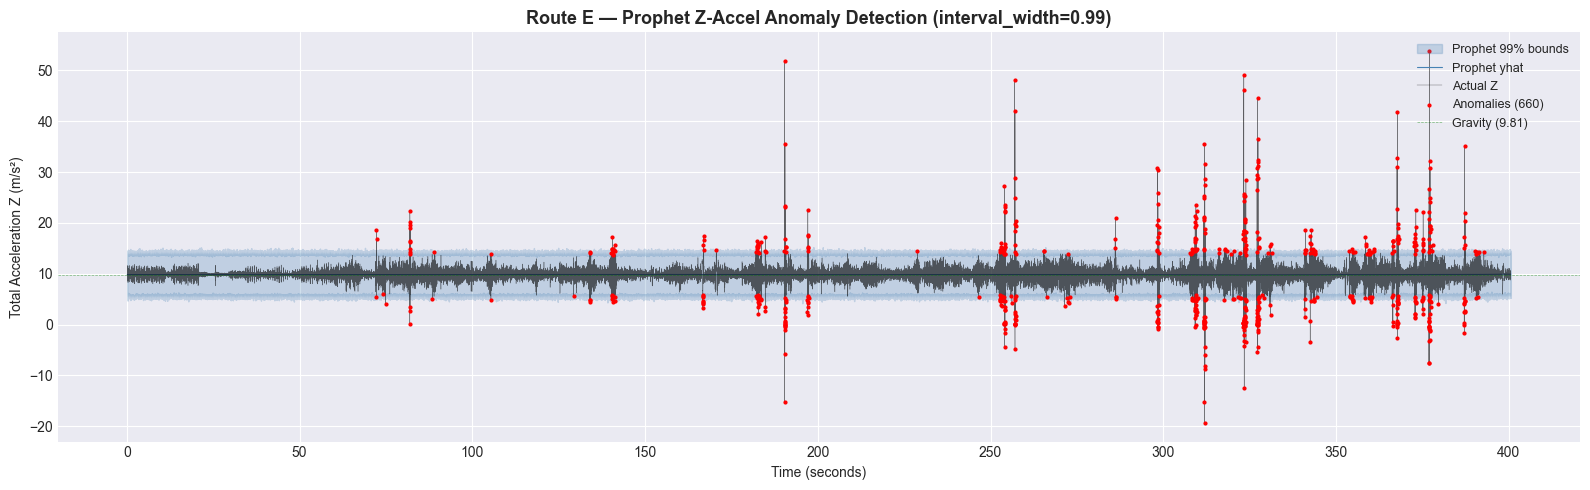

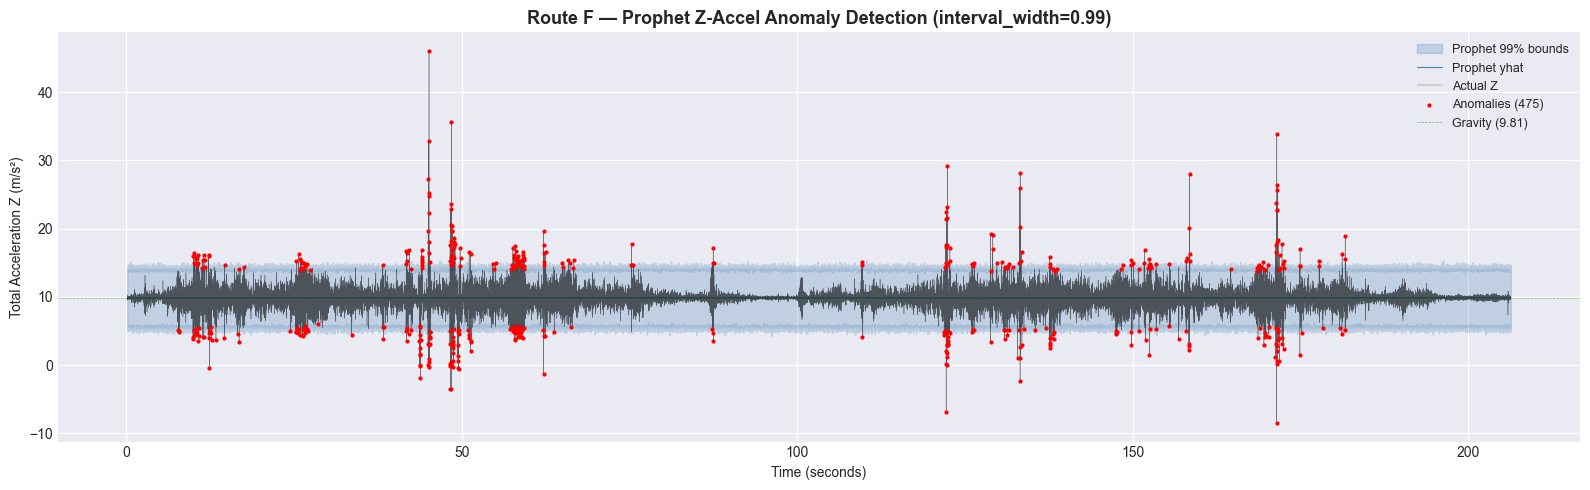

In [6]:
for folder in folders:
    total = all_data[folder]['total']
    r = results[folder]
    fc = r['forecast']
    t = total['seconds_elapsed'].values
    z = total['z'].values
    anom = r['anomaly']

    fig, ax = plt.subplots(figsize=(16, 5))
    
    # Prophet confidence band
    ax.fill_between(t, fc['yhat_lower'].values, fc['yhat_upper'].values,
                    alpha=0.25, color='steelblue', label='Prophet 99% bounds')
    ax.plot(t, fc['yhat'].values, color='steelblue', lw=0.8, label='Prophet yhat')
    
    # Actual Z signal
    ax.plot(t, z, color='black', lw=0.3, alpha=0.6, label='Actual Z')
    
    # Anomalies
    ax.scatter(t[anom], z[anom], c='red', s=4, zorder=5, label=f'Anomalies ({int(anom.sum())})')
    
    ax.axhline(9.81, color='green', ls='--', lw=0.5, alpha=0.5, label='Gravity (9.81)')
    ax.set_title(f'Route {folder} — Prophet Z-Accel Anomaly Detection (interval_width=0.99)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Total Acceleration Z (m/s²)')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. Build Segments → GPS Mapping → Feature Extraction

Group consecutive anomaly points into segments, map to GPS, extract features from **all sensors**:
- **TotalAccel Z**: dip magnitude, bump magnitude, deviation from bounds
- **Gyroscope**: rotation magnitude (pothole = high, braking = low)
- **Accelerometer X**: braking/acceleration (longitudinal)
- **Speed**: context for filtering

In [7]:
MIN_SPEED = 2.0  # m/s — ignore below this

def build_segments(seconds, anomalies):
    """Group consecutive anomaly points into segments."""
    segs = []
    in_seg = False
    for i, (t, a) in enumerate(zip(seconds, anomalies)):
        if a and not in_seg:
            in_seg, si, st = True, i, t
        elif not a and in_seg:
            in_seg = False
            segs.append({'si': si, 'ei': i, 'start': st, 'end': t})
    if in_seg:
        segs.append({'si': si, 'ei': len(seconds)-1,
                     'start': st, 'end': float(seconds.iloc[-1]) if hasattr(seconds, 'iloc') else float(seconds[-1])})
    return segs

def get_gps_at_time(loc_df, sec):
    idx = (loc_df['seconds_elapsed'] - sec).abs().idxmin()
    return loc_df.loc[idx]

def segments_to_events(total_df, gyro_df, accel_df, loc_df, segments,
                       speed_ctx, deviation_arr):
    """
    Convert anomaly segments to GPS-located events with multi-sensor features.
    """
    rows = []
    reject_counts = {'low_speed': 0, 'start_phase': 0, 'stop_phase': 0}

    for seg in segments:
        mid = (seg['start'] + seg['end']) / 2
        duration = seg['end'] - seg['start']

        # Speed context
        seg_ctx = speed_ctx[(speed_ctx['seconds_elapsed'] >= seg['start']) &
                            (speed_ctx['seconds_elapsed'] <= seg['end'])]
        if len(seg_ctx) == 0:
            idx = (speed_ctx['seconds_elapsed'] - mid).abs().idxmin()
            seg_ctx = speed_ctx.iloc[[idx]]

        avg_speed = float(seg_ctx['speed'].mean())
        any_start = bool(seg_ctx['is_start_phase'].any())
        any_stop = bool(seg_ctx['is_stop_phase'].any())

        # Filters
        if avg_speed < MIN_SPEED:
            reject_counts['low_speed'] += 1
            continue
        if any_start:
            reject_counts['start_phase'] += 1
            continue
        if any_stop:
            reject_counts['stop_phase'] += 1
            continue

        gps = get_gps_at_time(loc_df, mid)

        # ── TotalAccel Z features (from Prophet detection) ──────
        t_seg = total_df.iloc[seg['si']:seg['ei']+1]
        dev_seg = deviation_arr[seg['si']:seg['ei']+1]

        z_values = t_seg['z'].values
        z_min = float(z_values.min())       # lowest Z (dip = below 9.81)
        z_max = float(z_values.max())       # highest Z (bump = above 9.81)
        z_mean = float(z_values.mean())
        z_std = float(z_values.std()) if len(z_values) > 1 else 0.0

        # Prophet deviation features
        max_dip_dev = float(dev_seg.min())   # most negative = deepest dip
        max_bump_dev = float(dev_seg.max())  # most positive = highest bump
        abs_max_dev = float(np.abs(dev_seg).max())  # overall max deviation

        # ── Gyroscope features (key for classification) ──────
        g_mask = (gyro_df['seconds_elapsed'] >= seg['start']) & \
                 (gyro_df['seconds_elapsed'] <= seg['end'])
        g_seg = gyro_df[g_mask]
        if len(g_seg) > 0:
            gyro_mag = np.sqrt(g_seg['x']**2 + g_seg['y']**2 + g_seg['z']**2)
            gyro_peak = float(gyro_mag.max())
            gyro_rms = float(gyro_mag.mean())
        else:
            gyro_peak = gyro_rms = 0.0

        # ── Accelerometer X features (braking/acceleration) ──────
        a_mask = (accel_df['seconds_elapsed'] >= seg['start']) & \
                 (accel_df['seconds_elapsed'] <= seg['end'])
        a_seg = accel_df[a_mask]
        if len(a_seg) > 0:
            accel_x_min = float(a_seg['x'].min())   # most negative = braking
            accel_x_max = float(a_seg['x'].max())   # most positive = accelerating
            accel_x_peak = float(a_seg['x'].abs().max())
        else:
            accel_x_min = accel_x_max = accel_x_peak = 0.0

        # ── Temporal context: braking before/after ──────
        pre_mask = (accel_df['seconds_elapsed'] >= seg['start'] - 1.0) & \
                   (accel_df['seconds_elapsed'] < seg['start'])
        pre_seg = accel_df[pre_mask]
        braking_before = bool(len(pre_seg) > 0 and float(pre_seg['x'].min()) < -1.5)

        post_mask = (accel_df['seconds_elapsed'] > seg['end']) & \
                    (accel_df['seconds_elapsed'] <= seg['end'] + 1.0)
        post_seg = accel_df[post_mask]
        braking_after = bool(len(post_seg) > 0 and float(post_seg['x'].min()) < -1.5)

        rows.append({
            'start_sec': seg['start'], 'end_sec': seg['end'],
            'duration': duration,
            'latitude': gps['latitude'], 'longitude': gps['longitude'],
            'speed': avg_speed,
            # Z-accel (Prophet-detected)
            'z_min': z_min, 'z_max': z_max, 'z_mean': z_mean, 'z_std': z_std,
            'max_dip_dev': max_dip_dev,       # deviation below lower bound (negative)
            'max_bump_dev': max_bump_dev,     # deviation above upper bound (positive)
            'abs_max_dev': abs_max_dev,       # overall severity proxy
            # Gyroscope
            'gyro_peak': gyro_peak,
            'gyro_rms': gyro_rms,
            # Accelerometer X (braking)
            'accel_x_min': accel_x_min,
            'accel_x_max': accel_x_max,
            'accel_x_peak': accel_x_peak,
            # Context
            'braking_before': braking_before,
            'braking_after': braking_after,
            'est_size_m': avg_speed * duration,
        })

    return pd.DataFrame(rows), reject_counts


# Process all routes
all_events = {}
for folder in folders:
    d = all_data[folder]
    r = results[folder]
    total = d['total']
    segs = build_segments(total['seconds_elapsed'], r['anomaly'])
    df, rejects = segments_to_events(
        total, d['gyro'], d['accel'], d['location'],
        segs, d['speed_ctx'], r['deviation']
    )
    all_events[folder] = df
    n_total = len(segs)
    n_kept = len(df)
    print(f'\nRoute {folder}: {n_total} raw segments → {n_kept} kept')
    print(f'  Rejected: low_speed={rejects["low_speed"]}, '
          f'start_phase={rejects["start_phase"]}, '
          f'stop_phase={rejects["stop_phase"]}')

total_kept = sum(len(d) for d in all_events.values())
print(f'\nTotal events after filtering: {total_kept}')


Route A: 213 raw segments → 203 kept
  Rejected: low_speed=10, start_phase=0, stop_phase=0

Route B: 630 raw segments → 410 kept
  Rejected: low_speed=144, start_phase=67, stop_phase=9

Route C: 156 raw segments → 156 kept
  Rejected: low_speed=0, start_phase=0, stop_phase=0

Route D: 550 raw segments → 501 kept
  Rejected: low_speed=49, start_phase=0, stop_phase=0

Route E: 337 raw segments → 333 kept
  Rejected: low_speed=3, start_phase=1, stop_phase=0

Route F: 312 raw segments → 302 kept
  Rejected: low_speed=7, start_phase=3, stop_phase=0

Total events after filtering: 1905


## 6. Classification — Gyro for Pothole, X-Accel for Braking

**Logic:**
- **Pothole**: Z went below lower bound (dip) + **gyro_peak > threshold** (vehicle rocked/tilted)
- **Hard Braking**: Strong X-accel (longitudinal) + **low gyro** (vehicle didn't rock vertically)
- **Acceleration/Deceleration**: Moderate X-accel + low gyro
- **Speed Breaker**: Z oscillates up AND down + longer duration + moderate gyro
- **Road Bump**: Z went above upper bound only (uplift, not dip)
- **Severity**: Based on how far outside Prophet's bounds (`abs_max_dev`)

In [8]:
def classify_event(row):
    """
    Classify using Prophet deviation + gyroscope + X-accelerometer.
    Returns (label, severity, confidence).
    """
    dip_dev   = row['max_dip_dev']       # negative = below lower bound
    bump_dev  = row['max_bump_dev']      # positive = above upper bound
    abs_dev   = row['abs_max_dev']       # overall max deviation
    z_min     = row['z_min']             # raw Z minimum
    z_max     = row['z_max']             # raw Z maximum
    z_std     = row['z_std']             # Z variability
    g_peak    = row['gyro_peak']         # max gyro rotation
    g_rms     = row['gyro_rms']          # avg gyro rotation
    x_min     = row['accel_x_min']       # most negative X = braking
    x_max     = row['accel_x_max']       # most positive X = accelerating
    x_peak    = row['accel_x_peak']      # absolute max X
    dur       = row['duration']
    speed     = row['speed']
    brk_bef   = row['braking_before']
    brk_aft   = row['braking_after']

    has_dip  = dip_dev < -0.5            # significant downward deviation
    has_bump = bump_dev > 0.5            # significant upward deviation
    dip_mag  = abs(dip_dev)              # positive magnitude of dip
    bump_mag = bump_dev                  # positive magnitude of bump

    # ═══════════════════════════════════════════════════════
    # 1. HARD BRAKING / ACCELERATION
    #    Strong longitudinal force + LOW gyro = driver behavior, not road
    # ═══════════════════════════════════════════════════════
    if x_peak > 2.0 and g_peak < 0.3 and abs_dev < 2.0:
        severity = min(10, x_peak * 1.5)
        if x_min < -2.5:
            return 'Hard Braking', severity, 0.80
        elif x_max > 2.5:
            return 'Acceleration', severity, 0.75
        return 'Hard Braking' if abs(x_min) > x_max else 'Acceleration', severity, 0.70

    # Braking context before + low vertical = braking vibration
    if brk_bef and g_peak < 0.3 and abs_dev < 2.0:
        severity = min(10, x_peak * 1.2)
        return 'Hard Braking', severity, 0.65

    # ═══════════════════════════════════════════════════════
    # 2. ROAD BUMP: Z went UP only (above upper bound), not down
    #    Uplift = speed breaker, construction patch, joint
    # ═══════════════════════════════════════════════════════
    if has_bump and not has_dip:
        severity = min(10, bump_mag * 1.5)
        if dur > 0.15 and bump_mag > 2.0:
            return 'Speed Breaker', severity, 0.70
        return 'Road Bump', severity, 0.50

    # ═══════════════════════════════════════════════════════
    # 3. SPEED BREAKER: both dip AND bump + longer duration
    #    Vehicle goes up-then-down or down-then-up over a hump
    # ═══════════════════════════════════════════════════════
    if has_dip and has_bump and dur > 0.15 and g_peak < 0.8:
        total_osc = dip_mag + bump_mag
        if total_osc > 3.0 or (bump_mag > dip_mag * 0.5 and bump_mag > 1.0):
            severity = min(10, total_osc * 0.8)
            return 'Speed Breaker', severity, 0.65

    # ═══════════════════════════════════════════════════════
    # 4. POTHOLE: Z went BELOW lower bound + gyro confirms
    #    Wheel drops into hole → freefall → gyro spike from tilt
    #    GYRO is the key discriminator: pothole rocks the vehicle
    # ═══════════════════════════════════════════════════════
    if has_dip:
        # Severity from Prophet deviation (how far outside bounds)
        severity = min(10, dip_mag * 1.2 + g_peak * 2.0)

        # High gyro = confirmed pothole (vehicle tilted/rocked)
        if g_peak > 0.3:
            confidence = min(0.95, 0.65 + dip_mag * 0.05 + g_peak * 0.15)
            if brk_aft:
                confidence = min(1.0, confidence + 0.05)
            return 'Pothole', severity, confidence

        # Large Z deviation alone (deep dip) even with low gyro
        if dip_mag > 3.0:
            return 'Pothole', severity, 0.55

        # Moderate dip + some gyro
        if dip_mag > 1.5 and g_peak > 0.15:
            return 'Pothole', severity, 0.50

        # Small dip — might be road texture
        return 'Rough Patch', min(5, dip_mag * 0.8), 0.30

    # ═══════════════════════════════════════════════════════
    # 5. MINOR ANOMALY: barely outside bounds
    # ═══════════════════════════════════════════════════════
    severity = min(4, abs_dev * 0.5)
    return 'Minor Anomaly', severity, 0.20


# Apply classification
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        continue
    classified = df.apply(classify_event, axis=1, result_type='expand')
    df['event_type'] = classified[0]
    df['severity'] = classified[1].astype('float32')
    df['confidence'] = classified[2].astype('float32')
    df['route'] = folder
    all_events[folder] = df

# Show distribution
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        print(f'Route {folder}: no events')
        continue
    print(f'\nRoute {folder} ({len(df)} events):')
    print(df['event_type'].value_counts().to_string())
    for etype in ['Pothole', 'Hard Braking']:
        sub = df[df['event_type'] == etype]
        if len(sub) > 0:
            print(f'  → {etype}: {len(sub)} (avg sev: {sub["severity"].mean():.1f}, '
                  f'avg conf: {sub["confidence"].mean():.2f}, '
                  f'avg gyro: {sub["gyro_peak"].mean():.3f})')


Route A (203 events):
event_type
Minor Anomaly    66
Hard Braking     43
Road Bump        36
Rough Patch      33
Pothole          24
Acceleration      1
  → Pothole: 24 (avg sev: 5.3, avg conf: 0.67, avg gyro: 0.366)
  → Hard Braking: 43 (avg sev: 1.1, avg conf: 0.65, avg gyro: 0.145)

Route B (410 events):
event_type
Minor Anomaly    275
Rough Patch       65
Road Bump         41
Hard Braking      29
  → Hard Braking: 29 (avg sev: 0.8, avg conf: 0.66, avg gyro: 0.041)

Route C (156 events):
event_type
Hard Braking     46
Road Bump        36
Pothole          31
Minor Anomaly    25
Rough Patch      16
Acceleration      2
  → Pothole: 31 (avg sev: 5.3, avg conf: 0.82, avg gyro: 0.690)
  → Hard Braking: 46 (avg sev: 0.9, avg conf: 0.65, avg gyro: 0.103)

Route D (501 events):
event_type
Hard Braking     197
Minor Anomaly    135
Road Bump         60
Rough Patch       59
Pothole           49
Acceleration       1
  → Pothole: 49 (avg sev: 4.4, avg conf: 0.73, avg gyro: 0.433)
  → Hard Brakin

## 7. DBSCAN Spatial Clustering
Merge nearby detections within 30m into single events. Keep max severity and most common type.

In [10]:
CLUSTER_RADIUS_M = 20  # smaller to avoid merging distinct spots

def cluster_events(df, eps_m=CLUSTER_RADIUS_M):
    """Cluster events SEPARATELY by type so potholes don't merge with braking."""
    if len(df) == 0:
        return df

    all_rows = []
    for etype, grp in df.groupby('event_type'):
        if len(grp) == 0:
            continue
        grp = grp.copy()
        coords_rad = np.radians(grp[['latitude', 'longitude']].values)
        eps_rad = eps_m / 6371000.0
        db = DBSCAN(eps=eps_rad, min_samples=1, metric='haversine')
        grp['cluster'] = db.fit_predict(coords_rad)

        for cid, cgrp in grp.groupby('cluster'):
            all_rows.append({
                'latitude': cgrp['latitude'].mean(),
                'longitude': cgrp['longitude'].mean(),
                'event_type': etype,
                'severity': cgrp['severity'].max(),
                'avg_severity': cgrp['severity'].mean(),
                'confidence': cgrp['confidence'].max(),
                'n_detections': len(cgrp),
                'total_duration': cgrp['duration'].sum(),
                'max_gyro_peak': cgrp['gyro_peak'].max(),
                'max_dip_dev': cgrp['max_dip_dev'].min(),    # most negative = deepest
                'max_bump_dev': cgrp['max_bump_dev'].max(),
                'abs_max_dev': cgrp['abs_max_dev'].max(),
                'max_accel_x': cgrp['accel_x_peak'].max(),
                'avg_speed': cgrp['speed'].mean(),
                'est_size_m': cgrp['est_size_m'].max(),
                'route': cgrp['route'].iloc[0],
            })

    return pd.DataFrame(all_rows)


clustered = {}
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        clustered[folder] = pd.DataFrame()
        continue
    c = cluster_events(df)
    clustered[folder] = c
    print(f'Route {folder}: {len(df)} raw → {len(c)} clustered events')
    print(f'  {dict(c["event_type"].value_counts())}')

dfs = [d for d in clustered.values() if len(d) > 0]
all_clustered = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f'\nTotal clustered events: {len(all_clustered)}')
if len(all_clustered) > 0:
    print('\nDistribution:')
    print(all_clustered['event_type'].value_counts().to_string())
    print(f'\nPotholes: {len(all_clustered[all_clustered["event_type"]=="Pothole"])}')
    print(f'Hard Braking: {len(all_clustered[all_clustered["event_type"]=="Hard Braking"])}')


Route A: 203 raw → 51 clustered events
  {'Minor Anomaly': np.int64(14), 'Road Bump': np.int64(11), 'Rough Patch': np.int64(10), 'Hard Braking': np.int64(8), 'Pothole': np.int64(7), 'Acceleration': np.int64(1)}
Route B: 410 raw → 24 clustered events
  {'Rough Patch': np.int64(9), 'Road Bump': np.int64(8), 'Minor Anomaly': np.int64(5), 'Hard Braking': np.int64(2)}
Route C: 156 raw → 63 clustered events
  {'Minor Anomaly': np.int64(15), 'Road Bump': np.int64(12), 'Rough Patch': np.int64(12), 'Hard Braking': np.int64(11), 'Pothole': np.int64(11), 'Acceleration': np.int64(2)}
Route D: 501 raw → 50 clustered events
  {'Road Bump': np.int64(11), 'Rough Patch': np.int64(11), 'Minor Anomaly': np.int64(10), 'Hard Braking': np.int64(10), 'Pothole': np.int64(7), 'Acceleration': np.int64(1)}
Route E: 333 raw → 91 clustered events
  {'Road Bump': np.int64(23), 'Minor Anomaly': np.int64(19), 'Pothole': np.int64(18), 'Hard Braking': np.int64(16), 'Rough Patch': np.int64(11), 'Acceleration': np.int64(

## 8. Severity Score — How Far Outside Prophet's Bounds

$\text{importance\_score} = \frac{|y_{\text{actual}} - y_{\text{bound}}|}{\sigma_{\text{bounds}}}$

Events that deviate far from the 99% confidence interval are most severe.

In [11]:
if len(all_clustered) > 0:
    print('='*70)
    print('ROAD ANALYSIS SUMMARY')
    print('='*70)

    for folder in folders:
        df = clustered[folder]
        if len(df) == 0:
            print(f'\nRoute {folder}: No events.')
            continue
        print(f'\nRoute {folder}: {len(df)} events')
        print(f'  {dict(df["event_type"].value_counts())}')
        for etype in ['Pothole', 'Hard Braking', 'Speed Breaker']:
            sub = df[df['event_type'] == etype]
            if len(sub) > 0:
                print(f'  {etype}: {len(sub)} | max severity: {sub["severity"].max():.1f} | '
                      f'avg conf: {sub["confidence"].mean():.2f}')

    print(f'\n{"="*70}')
    print(f'Total: {len(all_clustered)} events')
    print(all_clustered['event_type'].value_counts().to_string())

    all_clustered.to_csv('road_events_v3.csv', index=False)
    print('\nExported → road_events_v3.csv')
    display(all_clustered.head(15))
else:
    print('No events detected.')

ROAD ANALYSIS SUMMARY

Route A: 51 events
  {'Minor Anomaly': np.int64(14), 'Road Bump': np.int64(11), 'Rough Patch': np.int64(10), 'Hard Braking': np.int64(8), 'Pothole': np.int64(7), 'Acceleration': np.int64(1)}
  Pothole: 7 | max severity: 10.0 | avg conf: 0.83
  Hard Braking: 8 | max severity: 4.1 | avg conf: 0.67

Route B: 24 events
  {'Rough Patch': np.int64(9), 'Road Bump': np.int64(8), 'Minor Anomaly': np.int64(5), 'Hard Braking': np.int64(2)}
  Hard Braking: 2 | max severity: 4.2 | avg conf: 0.73

Route C: 63 events
  {'Minor Anomaly': np.int64(15), 'Road Bump': np.int64(12), 'Rough Patch': np.int64(12), 'Hard Braking': np.int64(11), 'Pothole': np.int64(11), 'Acceleration': np.int64(2)}
  Pothole: 11 | max severity: 10.0 | avg conf: 0.78
  Hard Braking: 11 | max severity: 2.2 | avg conf: 0.65

Route D: 50 events
  {'Road Bump': np.int64(11), 'Rough Patch': np.int64(11), 'Minor Anomaly': np.int64(10), 'Hard Braking': np.int64(10), 'Pothole': np.int64(7), 'Acceleration': np.int6

,latitude,longitude,event_type,severity,avg_severity,confidence,n_detections,total_duration,max_gyro_peak,max_dip_dev,max_bump_dev,abs_max_dev,max_accel_x,avg_speed,est_size_m,route
0,30.653970,76.741244,Acceleration,3.850607,3.850607,0.75,1,0.020714,0.247715,-0.202389,0.856447,0.856447,2.567072,10.291052,0.213167,A
1,30.649269,76.740056,Hard Braking,3.574965,1.082925,0.70,5,0.062141,0.248673,-0.715667,0.902829,0.902829,2.383310,7.947909,0.166240,A
2,30.649391,76.740298,Hard Braking,4.064008,1.193855,0.80,9,0.124285,0.286350,-1.358443,0.988429,1.358443,2.709338,8.464869,0.178515,A
3,30.649905,76.741305,Hard Braking,0.482404,0.482404,0.65,1,0.010357,0.051355,0.000000,0.410972,0.410972,0.402003,9.550645,0.098915,A
4,30.651316,76.743441,Hard Braking,2.127596,1.337563,0.65,11,0.113914,0.259302,-1.182605,0.791744,1.182605,1.772997,4.666725,0.050200,A
5,30.652262,76.742791,Hard Braking,1.018791,1.018791,0.65,1,0.010353,0.158385,-1.493808,0.000000,1.493808,0.848993,7.003950,0.072513,A
6,30.653457,76.741850,Hard Braking,2.166185,1.314427,0.65,6,0.072510,0.241054,-0.803405,1.506600,1.506600,1.805154,5.625654,0.120381,A
7,30.654110,76.741071,Hard Braking,1.621437,0.752713,0.65,4,0.041443,0.101571,-1.405192,0.417873,1.405192,1.351197,9.544934,0.100378,A
8,30.654445,76.740668,Hard Braking,1.562930,0.715976,0.65,6,0.072525,0.270668,-1.310408,1.856009,1.856009,1.302441,6.901954,0.142650,A
9,30.648906,76.739433,Minor Anomaly,0.018201,0.018201,0.20,1,0.010334,0.049533,0.000000,0.036402,0.036402,0.141905,4.531793,0.046832,A


## 9. Interactive Leaflet Map
**Color legend:**
- 🔴 Red = Pothole (Z below bounds + gyro confirms)
- 🟢 Green = Road Bump (Z above bounds)
- 🟡 Yellow = Speed Breaker
- 🟤 Brown = Rough Patch
- 🟠 Orange = Hard Braking
- 🔵 Blue = Acceleration
- ⚪ Gray = Minor Anomaly

In [12]:
if len(all_clustered) == 0:
    print('Nothing to map.')
else:
    EVENT_COLORS = {
        'Pothole': 'red',
        'Road Bump': '#22AA22',
        'Speed Breaker': '#FFD700',
        'Rough Patch': '#8B4513',
        'Hard Braking': 'orange',
        'Acceleration': '#4488CC',
        'Minor Anomaly': '#AAAAAA',
    }
    EVENT_OPACITY = {
        'Pothole': 0.9,
        'Road Bump': 0.5,
        'Speed Breaker': 0.7,
        'Rough Patch': 0.4,
        'Hard Braking': 0.3,
        'Acceleration': 0.25,
        'Minor Anomaly': 0.15,
    }
    ROUTE_COLORS = {'A':'red','B':'blue','C':'green','D':'orange','E':'purple','F':'darkred'}

    centre = [all_clustered['latitude'].mean(), all_clustered['longitude'].mean()]
    m = folium.Map(location=centre, zoom_start=14, tiles='OpenStreetMap')

    # Route paths
    for folder in folders:
        loc = all_data[folder]['location']
        coords = list(zip(loc['latitude'], loc['longitude']))
        folium.PolyLine(coords, color=ROUTE_COLORS[folder], weight=4,
                        opacity=0.6, tooltip=f'Route {folder}').add_to(m)

    # Event markers
    for _, row in all_clustered.iterrows():
        etype = row['event_type']
        color = EVENT_COLORS.get(etype, 'gray')
        opacity = EVENT_OPACITY.get(etype, 0.2)
        sev = row['severity']
        conf = row['confidence']

        if etype == 'Pothole':
            radius = max(8, min(20, sev * 2.2))
        elif etype in ('Speed Breaker', 'Road Bump'):
            radius = max(5, min(12, sev * 1.3))
        else:
            radius = 3

        popup = (f'<b>{etype}</b> (Route {row["route"]})<br>'
                 f'Severity: {sev:.1f}/10<br>'
                 f'Confidence: {conf:.0%}<br>'
                 f'Prophet dip deviation: {row.get("max_dip_dev", 0):.2f} m/s²<br>'
                 f'Prophet bump deviation: {row.get("max_bump_dev", 0):.2f} m/s²<br>'
                 f'Max gyro: {row["max_gyro_peak"]:.3f} rad/s<br>'
                 f'Detections merged: {int(row["n_detections"])}<br>'
                 f'Speed: {row["avg_speed"]:.1f} m/s ({row["avg_speed"]*3.6:.0f} km/h)<br>'
                 f'<a href="https://www.google.com/maps?q={row["latitude"]},{row["longitude"]}" '
                 f'target="_blank">Google Maps</a>')

        folium.CircleMarker(
            [row['latitude'], row['longitude']],
            radius=radius, color=color, fill=True,
            fill_color=color, fill_opacity=opacity,
            popup=folium.Popup(popup, max_width=300),
            tooltip=f'{etype} | sev={sev:.1f} | conf={conf:.0%}'
        ).add_to(m)

    # Legend
    legend_html = '''
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999;
                background:white; padding:12px; border:2px solid gray;
                border-radius:8px; font-size:13px; opacity:0.92;">
    <b>Road Surface (Prophet Z-Accel)</b><br>
    <span style="color:red">&#11044;</span> Pothole (Z dip + gyro)<br>
    <span style="color:#22AA22">&#11044;</span> Road Bump (Z uplift)<br>
    <span style="color:#FFD700">&#11044;</span> Speed Breaker<br>
    <span style="color:#8B4513">&#11044;</span> Rough Patch<br>
    <br><b>Driver Behavior</b><br>
    <span style="color:orange">&#11044;</span> Hard Braking<br>
    <span style="color:#4488CC">&#11044;</span> Acceleration<br>
    <span style="color:#AAAAAA">&#11044;</span> Minor Anomaly<br>
    <br><b>Routes</b><br>
    <span style="color:red">&#9473;</span> A &nbsp;
    <span style="color:blue">&#9473;</span> B &nbsp;
    <span style="color:green">&#9473;</span> C<br>
    <span style="color:orange">&#9473;</span> D &nbsp;
    <span style="color:purple">&#9473;</span> E &nbsp;
    <span style="color:darkred">&#9473;</span> F
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl().add_to(m)
    m.save('road_analysis_v3_map.html')
    print('Saved → road_analysis_v3_map.html')
    m

Saved → road_analysis_v3_map.html
